# Пункт 1: распределения по трём ошибкам

Здесь только первый пункт задания.

Смотрим 3 ошибки:
- потеря KV-кэша
- Resource Abuse
- таймауты вызовов инструментов

Что считаю:
- частоты
- доли
- среднее / мат. ожидание
- медиану
- квантили
- гистограммы

Соответствия беру из файла `fault_mode_analysis_and_classification_ru.docx`:
- **Потеря KV-кэша** -> `Context Handling Failures`
- **Resource Abuse** -> `Resource Abuse`
- **Таймауты вызовов инструментов** -> `Timeout Issues` и `Service Errors`

Данные читаются из локальной папки проекта `data/huggingface`. Для TRAIL используется `processed_annotations_*`, для Who&When - JSON-зеркало `Who&When/*/*.json`. Это убирает зависимость от `pyarrow` и от абсолютных путей на конкретной машине.


In [2]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
pd.set_option('display.max_colwidth', 200)

CATEGORY_ALIASES = {
    'Context Handling Failure': 'Context Handling Failures',
    'Formatting Error': 'Formatting Errors',
    'Goal deviation': 'Goal Deviation',
    'Instruction Non-Compliance': 'Instruction Non-compliance',
    'Instruction non complience': 'Instruction Non-compliance',
    'Language-Only': 'Language-only',
    'Poor Information retrieval': 'Poor Information Retrieval',
    'Task Orchestration Error': 'Task Orchestration',
    'Task Orchestration Errors': 'Task Orchestration',
    'Tool Selection': 'Tool Selection Errors',
}


def normalize_category(category: object) -> str:
    value = str(category or '').strip()
    return CATEGORY_ALIASES.get(value, value or '<missing>')


In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        has_trail = (candidate / 'data' / 'huggingface' / 'PatronusAI__TRAIL').exists()
        has_who_when = (candidate / 'data' / 'huggingface' / 'Kevin355__Who_and_When').exists()
        if has_trail and has_who_when:
            return candidate
    raise FileNotFoundError(
        'Не нашел корень проекта с data/huggingface. '
        'Запусти ноутбук из репозитория raspredel или задай рабочую директорию внутри него.'
    )

PROJECT_ROOT = find_project_root()
TRAIL_ROOT = PROJECT_ROOT / 'data' / 'huggingface' / 'PatronusAI__TRAIL'
WHO_WHEN_ROOT = PROJECT_ROOT / 'data' / 'huggingface' / 'Kevin355__Who_and_When'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('TRAIL_ROOT =', TRAIL_ROOT)
print('WHO_WHEN_ROOT =', WHO_WHEN_ROOT)


PROJECT_ROOT = C:\Users\kameel\Repositories\raspredel
TRAIL_ROOT = C:\Users\kameel\Repositories\raspredel\data\huggingface\PatronusAI__TRAIL
WHO_WHEN_ROOT = C:\Users\kameel\Repositories\raspredel\data\huggingface\Kevin355__Who_and_When


In [4]:
def read_json_loose(path: Path) -> dict:
    text = path.read_text(encoding='utf-8')
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        # В нескольких TRAIL annotation-файлах встречаются trailing commas.
        text = re.sub(r',\s*([}\]])', r'\1', text)
        return json.loads(text)


def load_trail_annotations(root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    trace_rows = []
    error_rows = []
    sources = [
        (root / 'processed_annotations_gaia', 'GAIA'),
        (root / 'processed_annotations_swe_bench', 'SWE-bench'),
    ]

    for ann_dir, benchmark in sources:
        if not ann_dir.exists():
            raise FileNotFoundError(f'Не найдена папка TRAIL annotations: {ann_dir}')

        for path in sorted(ann_dir.glob('*.json')):
            labels = read_json_loose(path)
            trace_id = labels.get('trace_id') or path.stem
            trace_key = f'{benchmark}:{trace_id}'
            errors = labels.get('errors', [])

            trace_rows.append({
                'trace_key': trace_key,
                'trace_id': trace_id,
                'benchmark': benchmark,
                'source_file': path.name,
                'errors_n': len(errors),
            })

            for err in errors:
                error_rows.append({
                    'trace_key': trace_key,
                    'trace_id': trace_id,
                    'benchmark': benchmark,
                    'category': normalize_category(err.get('category')),
                    'impact': err.get('impact'),
                    'location': err.get('location'),
                    'description': err.get('description'),
                    'evidence': err.get('evidence'),
                })

    trace_columns = ['trace_key', 'trace_id', 'benchmark', 'source_file', 'errors_n']
    error_columns = ['trace_key', 'trace_id', 'benchmark', 'category', 'impact', 'location', 'description', 'evidence']
    return pd.DataFrame(trace_rows, columns=trace_columns), pd.DataFrame(error_rows, columns=error_columns)


def load_who_when(root: Path) -> pd.DataFrame:
    rows = []
    data_root = root / 'Who&When'
    sources = [
        (data_root / 'Algorithm-Generated', 'Algorithm-Generated'),
        (data_root / 'Hand-Crafted', 'Hand-Crafted'),
    ]

    for split_dir, split in sources:
        if not split_dir.exists():
            raise FileNotFoundError(f'Не найдена папка Who&When split: {split_dir}')

        for path in sorted(split_dir.glob('*.json')):
            obj = json.loads(path.read_text(encoding='utf-8'))
            row = dict(obj)
            row['split'] = split
            row['source_file'] = path.name
            rows.append(row)

    ww = pd.DataFrame(rows)
    ww['mistake_step_num'] = pd.to_numeric(ww['mistake_step'], errors='coerce')
    ww['mistake_reason'] = ww['mistake_reason'].fillna('')
    ww['history_len'] = ww['history'].apply(lambda x: len(x) if hasattr(x, '__len__') else np.nan)
    return ww


trail_traces, trail_errors = load_trail_annotations(TRAIL_ROOT)
ww = load_who_when(WHO_WHEN_ROOT)

print('TRAIL traces:', len(trail_traces))
print('TRAIL error annotations:', len(trail_errors))
print('Who&When cases:', len(ww))


TRAIL traces: 148
TRAIL error annotations: 841
Who&When cases: 184


## Какие строки беру в работу

### TRAIL
- Потеря KV-кэша -> `Context Handling Failures`
- Resource Abuse -> `Resource Abuse`
- Таймауты вызовов инструментов -> `Timeout Issues` и `Service Errors`

### Who&When
- Потеря KV-кэша -> случаи про потерю/игнорирование состояния и контекста
- Таймауты вызовов инструментов -> случаи про runtime / tool interruption / timeout
- Resource Abuse -> в сыром Who&When нет отдельной готовой метки, поэтому здесь его не вытаскиваю из Who&When отдельно


In [5]:
TRAIL_RULES = {
    'Потеря KV-кэша': trail_errors['category'].eq('Context Handling Failures'),
    'Resource Abuse': trail_errors['category'].eq('Resource Abuse'),
    'Таймауты вызовов инструментов': trail_errors['category'].isin(['Timeout Issues', 'Service Errors']),
}

WW_RULES = {
    'Потеря KV-кэша': ww['mistake_reason'].str.contains(
        r'context|previous constraint|previous state|retain|retention|forgot|forget|memory|state',
        case=False,
        regex=True,
    ),
    'Таймауты вызовов инструментов': ww['mistake_reason'].str.contains(
        r'timeout|timed out|runtime|tool interruption|tool failed|request failed|service|provider|tool call',
        case=False,
        regex=True,
    ),
}

for name, mask in TRAIL_RULES.items():
    trail_errors[name] = mask
    affected_trace_keys = set(trail_errors.loc[mask, 'trace_key'])
    trail_traces[name] = trail_traces['trace_key'].isin(affected_trace_keys)

for name, mask in WW_RULES.items():
    ww[name] = mask

In [6]:
def summarize_trail(name: str) -> dict:
    df = trail_errors[trail_errors[name]].copy()
    per_trace_all = df.groupby('trace_key').size().reindex(trail_traces['trace_key'], fill_value=0)
    per_affected_trace = per_trace_all[per_trace_all > 0]
    affected_traces_n = int(trail_traces[name].sum())

    return {
        'error': name,
        'annotations_n': len(df),
        'annotations_share_%': round(100 * len(df) / len(trail_errors), 2),
        'total_traces_n': len(trail_traces),
        'affected_traces_n': affected_traces_n,
        'affected_traces_share_%': round(100 * affected_traces_n / len(trail_traces), 2),
        'mean_per_trace': round(float(per_trace_all.mean()), 3),
        'median_per_trace': round(float(per_trace_all.median()), 3),
        'q25_per_trace': round(float(per_trace_all.quantile(0.25)), 3),
        'q75_per_trace': round(float(per_trace_all.quantile(0.75)), 3),
        'q90_per_trace': round(float(per_trace_all.quantile(0.90)), 3),
        'mean_per_affected_trace': round(float(per_affected_trace.mean()), 3) if len(per_affected_trace) else np.nan,
        'median_per_affected_trace': round(float(per_affected_trace.median()), 3) if len(per_affected_trace) else np.nan,
        'high_impact_share_%': round(100 * (df['impact'] == 'HIGH').mean(), 2) if len(df) else np.nan,
    }

trail_summary = pd.DataFrame([summarize_trail(name) for name in TRAIL_RULES])
trail_summary

,error,annotations_n,annotations_share_%,total_traces_n,affected_traces_n,affected_traces_share_%,mean_per_trace,median_per_trace,q25_per_trace,q75_per_trace,q90_per_trace,mean_per_affected_trace,median_per_affected_trace,high_impact_share_%
0,Потеря KV-кэша,47,5.59,148,44,29.73,0.318,0.0,0.0,1.0,1.0,1.068,1.0,34.04
1,Resource Abuse,57,6.78,148,42,28.38,0.385,0.0,0.0,1.0,1.0,1.357,1.0,14.04
2,Таймауты вызовов инструментов,4,0.48,148,4,2.70,0.027,0.0,0.0,0.0,0.0,1.000,1.0,75.00



Потеря KV-кэша


,impact,count
0,MEDIUM,31
1,HIGH,16


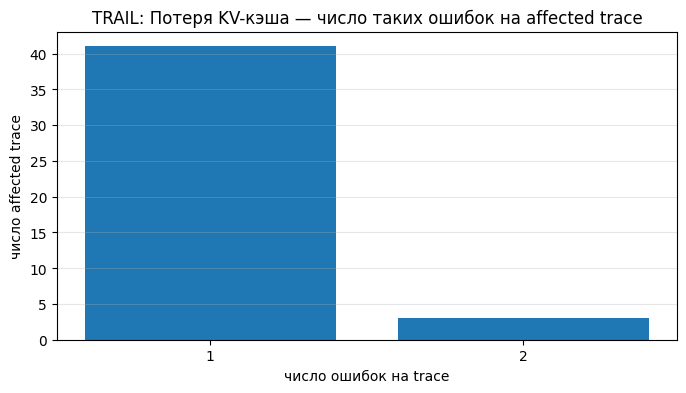


Resource Abuse


,impact,count
0,MEDIUM,47
1,HIGH,8
2,LOW,2


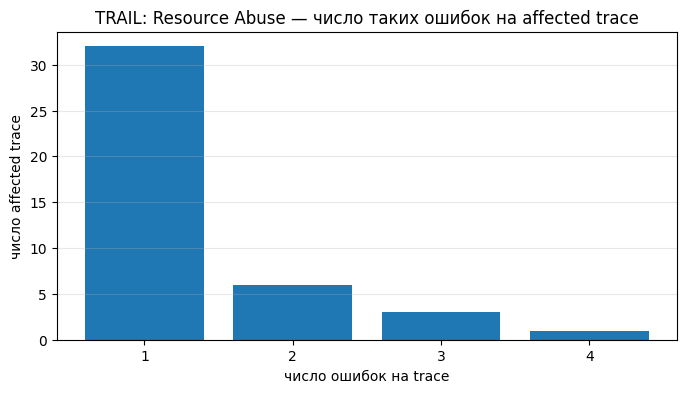


Таймауты вызовов инструментов


,impact,count
0,HIGH,3
1,MEDIUM,1


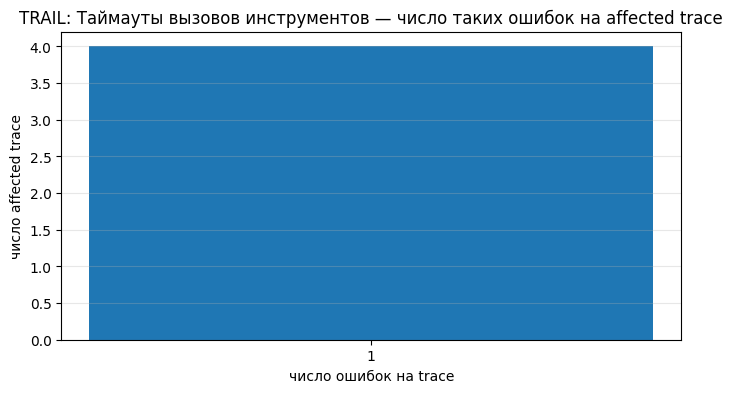

In [7]:
for name in TRAIL_RULES:
    df = trail_errors[trail_errors[name]].copy()
    per_trace = df.groupby('trace_key').size()

    print('\n' + name)
    display(df['impact'].value_counts(dropna=False).rename_axis('impact').reset_index(name='count'))

    if len(per_trace):
        counts = per_trace.value_counts().sort_index()
    
        plt.figure()
        plt.bar(counts.index.astype(int), counts.values)
    
        plt.title(f'TRAIL: {name} — число таких ошибок на affected trace')
        plt.xlabel('число ошибок на trace')
        plt.ylabel('число affected trace')
    
        plt.xticks(counts.index.astype(int))
        plt.grid(axis='y', alpha=0.3)
        plt.show()

In [8]:
def summarize_ww(name: str) -> dict:
    df = ww[ww[name]].copy()
    steps = df['mistake_step_num'].dropna()
    history = df['history_len'].dropna()

    return {
        'error': name,
        'cases_n': len(df),
        'cases_share_%': round(100 * len(df) / len(ww), 2),
        'step_mean': round(float(steps.mean()), 3) if len(steps) else np.nan,
        'step_median': round(float(steps.median()), 3) if len(steps) else np.nan,
        'step_q25': round(float(steps.quantile(0.25)), 3) if len(steps) else np.nan,
        'step_q75': round(float(steps.quantile(0.75)), 3) if len(steps) else np.nan,
        'step_q90': round(float(steps.quantile(0.90)), 3) if len(steps) else np.nan,
        'history_len_mean': round(float(history.mean()), 3) if len(history) else np.nan,
        'history_len_median': round(float(history.median()), 3) if len(history) else np.nan,
        'history_len_q25': round(float(history.quantile(0.25)), 3) if len(history) else np.nan,
        'history_len_q75': round(float(history.quantile(0.75)), 3) if len(history) else np.nan,
        'history_len_q90': round(float(history.quantile(0.90)), 3) if len(history) else np.nan,
    }

ww_summary = pd.DataFrame([summarize_ww(name) for name in WW_RULES])
ww_summary

,error,cases_n,cases_share_%,step_mean,step_median,step_q25,step_q75,step_q90,history_len_mean,history_len_median,history_len_q25,history_len_q75,history_len_q90
0,Потеря KV-кэша,4,2.17,3.0,1.5,1.0,3.5,6.2,15.25,8.5,7.75,16.0,28.6
1,Таймауты вызовов инструментов,1,0.54,15.0,15.0,15.0,15.0,15.0,21.00,21.0,21.00,21.0,21.0



Потеря KV-кэша


,split,mistake_agent,count
0,Algorithm-Generated,Behavioral_Expert,1
1,Algorithm-Generated,HawaiiRealEstate_Expert,1
2,Algorithm-Generated,Music_Critic_Expert,1
3,Hand-Crafted,WebSurfer,1


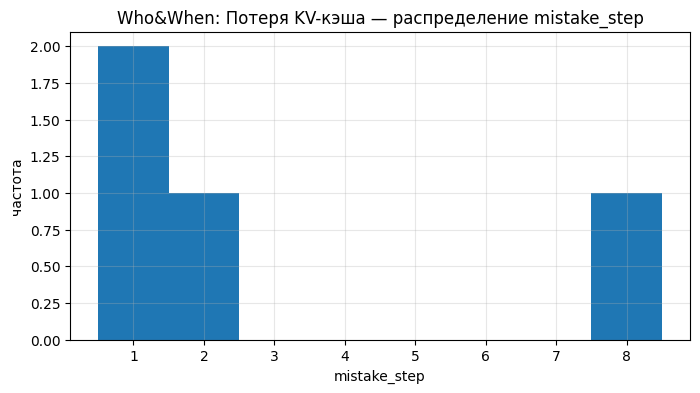


Таймауты вызовов инструментов


,split,mistake_agent,count
0,Hand-Crafted,Orchestrator,1


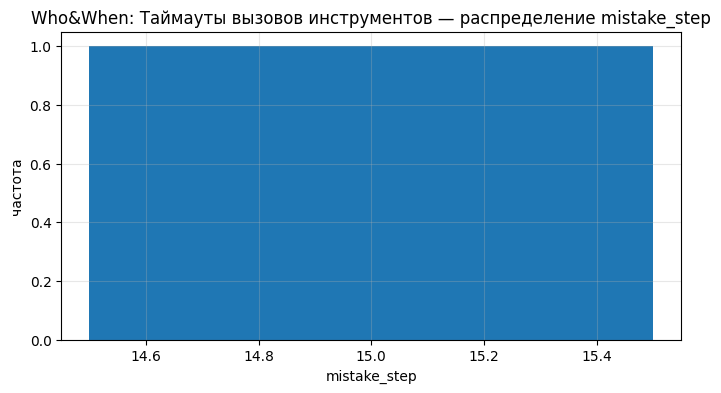

In [9]:
for name in WW_RULES:
    df = ww[ww[name]].copy()
    steps = df['mistake_step_num'].dropna()

    print('\n' + name)
    display(df[['split', 'mistake_agent']].value_counts().rename('count').reset_index().head(10))

    if len(steps):
        plt.figure()
        bins = np.arange(steps.min(), steps.max() + 2) - 0.5
        plt.hist(steps.values, bins=bins)
        plt.title(f'Who&When: {name} — распределение mistake_step')
        plt.xlabel('mistake_step')
        plt.ylabel('частота')
        plt.grid(True, alpha=0.3)
        plt.show()

## Результаты первого пункта

- По **TRAIL** отдельно считаются доли среди error annotations и доли affected traces от всех annotation-файлов, включая traces без ошибок.
- По **Who&When** полезнее всего смотреть `mistake_step`, `mistake_agent` и размер истории.
- Для **Resource Abuse** основной датасет здесь — **TRAIL**, потому что в сыром Who&When нет отдельной готовой метки под этот класс.
- Дальше уже можно переходить к пункту 2: смотреть зависимость от длины контекста и номера шага.

# Пункт 2: зависимость от длины контекста и шага в цепочке

Проверяю зависимость тремя способами:

- **Spearman**: монотонная связь между бинарным флагом ошибки и числовым признаком (`mistake_step`, число сообщений, token/char proxy контекста).
- **Точный тест Фишера**: 2x2 таблица `ошибка есть/нет` против `признак > median`. Это грубая, но устойчивая проверка для малых выборок.
- Для **TRAIL** считаю два уровня: trace-level вероятность ошибки и span/location-level положение ошибки внутри цепочки.

Интерпретация: положительный Spearman rho и Fisher odds ratio > 1 означают, что ошибка чаще встречается при больших значениях признака. При малом числе positives p-value имеет низкую мощность, поэтому такие строки помечаются как `low_positive_count`.


In [ ]:
from scipy import stats
import warnings


def coerce_float(value: object) -> float:
    try:
        if value is None or value == '':
            return np.nan
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def dependency_tests(df: pd.DataFrame, flags, predictors, dataset: str) -> pd.DataFrame:
    rows = []

    for error in flags:
        for predictor in predictors:
            data = df[[error, predictor]].copy()
            data[predictor] = pd.to_numeric(data[predictor], errors='coerce')
            data = data.dropna(subset=[error, predictor])

            if data.empty:
                rows.append({
                    'dataset': dataset,
                    'error': error,
                    'predictor': predictor,
                    'n': 0,
                    'positives': 0,
                    'predictor_median': np.nan,
                    'spearman_rho': np.nan,
                    'spearman_p': np.nan,
                    'fisher_odds_ratio': np.nan,
                    'fisher_p': np.nan,
                    'high_yes': 0,
                    'high_total': 0,
                    'low_yes': 0,
                    'low_total': 0,
                    'note': 'no_data',
                })
                continue

            y = data[error].astype(bool)
            x = data[predictor]
            n = int(len(data))
            positives = int(y.sum())
            median = float(x.median())

            if y.nunique() < 2 or x.nunique() < 2:
                rho = np.nan
                spearman_p = np.nan
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    rho, spearman_p = stats.spearmanr(x, y.astype(int))

            high = x > median
            low = ~high
            high_yes = int((high & y).sum())
            high_total = int(high.sum())
            low_yes = int((low & y).sum())
            low_total = int(low.sum())

            if high_total == 0 or low_total == 0 or y.nunique() < 2:
                odds_ratio = np.nan
                fisher_p = np.nan
            else:
                table = [
                    [high_yes, high_total - high_yes],
                    [low_yes, low_total - low_yes],
                ]
                odds_ratio, fisher_p = stats.fisher_exact(table, alternative='two-sided')

            note = ''
            if positives < 5:
                note = 'low_positive_count'

            rows.append({
                'dataset': dataset,
                'error': error,
                'predictor': predictor,
                'n': n,
                'positives': positives,
                'predictor_median': round(median, 3),
                'spearman_rho': round(float(rho), 4) if pd.notna(rho) else np.nan,
                'spearman_p': round(float(spearman_p), 4) if pd.notna(spearman_p) else np.nan,
                'fisher_odds_ratio': round(float(odds_ratio), 4) if pd.notna(odds_ratio) else np.nan,
                'fisher_p': round(float(fisher_p), 4) if pd.notna(fisher_p) else np.nan,
                'high_yes': high_yes,
                'high_total': high_total,
                'low_yes': low_yes,
                'low_total': low_total,
                'note': note,
            })

    return pd.DataFrame(rows)


def print_dependency_table(title: str, df: pd.DataFrame) -> None:
    cols = [
        'dataset', 'error', 'predictor', 'n', 'positives', 'predictor_median',
        'spearman_rho', 'spearman_p', 'fisher_odds_ratio', 'fisher_p',
        'high_yes', 'high_total', 'low_yes', 'low_total', 'note',
    ]
    print('')
    print(title)
    print(df[cols].to_string(index=False))


In [ ]:
def history_content_chars(history: object) -> float:
    if not isinstance(history, list):
        return np.nan

    total = 0
    for item in history:
        if isinstance(item, dict):
            total += len(str(item.get('content') or ''))
        else:
            total += len(str(item))
    return total


ww['history_chars'] = ww['history'].apply(history_content_chars)

ww_dependency = dependency_tests(
    ww,
    flags=WW_RULES.keys(),
    predictors=['mistake_step_num', 'history_len', 'history_chars'],
    dataset='Who&When cases',
)

print_dependency_table('Who&When: selected error flag vs mistake_step/context length', ww_dependency)



Who&When: selected error flag vs mistake_step/context length
       dataset                         error        predictor   n  positives  predictor_median  spearman_rho  spearman_p  fisher_odds_ratio  fisher_p  high_yes  high_total  low_yes  low_total               note
Who&When cases                Потеря KV-кэша mistake_step_num 184          4               4.0       -0.0657      0.3758             0.3984    0.6282         1          83        3        101 low_positive_count
Who&When cases                Потеря KV-кэша      history_len 184          4              10.0       -0.0596      0.4216             0.8205    1.0000         1          53        3        131 low_positive_count
Who&When cases                Потеря KV-кэша    history_chars 184          4           11296.0       -0.0603      0.4158             0.3260    0.6209         1          92        3         92 low_positive_count
Who&When cases Таймауты вызовов инструментов mistake_step_num 184          1               4.0

In [ ]:
TRAIL_RAW_DIRS = {
    'GAIA': TRAIL_ROOT / 'GAIA',
    'SWE-bench': TRAIL_ROOT / 'SWE Bench',
}


def parse_step_number(*values: object) -> float:
    for value in values:
        text = str(value or '')
        match = re.search(r'Step\s+(\d+)', text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))
        match = re.search(r'step_number=(\d+)', text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))
    return np.nan


def iter_nested_spans(spans: list, parent_span_id: str | None = None, depth: int = 0):
    for span in spans or []:
        yield span, parent_span_id, depth
        yield from iter_nested_spans(span.get('child_spans') or [], span.get('span_id'), depth + 1)


def raw_trace_path(row) -> Path:
    base = TRAIL_RAW_DIRS[row.benchmark]
    candidate = base / row.source_file
    if candidate.exists():
        return candidate
    return base / f'{row.trace_id}.json'


def load_trail_spans(traces: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in traces.itertuples(index=False):
        path = raw_trace_path(row)
        obj = json.loads(path.read_text(encoding='utf-8'))
        flat_spans = list(iter_nested_spans(obj.get('spans') or []))

        for span_order, (span, parent_span_id, depth) in enumerate(flat_spans, start=1):
            attrs = span.get('span_attributes') or {}
            span_id = str(span.get('span_id'))
            parent_location_key = f'{row.trace_key}:{parent_span_id}' if parent_span_id else None
            input_value = attrs.get('input.value')

            rows.append({
                'trace_key': row.trace_key,
                'trace_id': row.trace_id,
                'benchmark': row.benchmark,
                'span_id': span_id,
                'location_key': f'{row.trace_key}:{span_id}',
                'parent_location_key': parent_location_key,
                'span_order': span_order,
                'span_depth': depth,
                'span_name': span.get('span_name'),
                'span_kind': attrs.get('openinference.span.kind'),
                'direct_step_num': parse_step_number(span.get('span_name'), input_value),
                'prompt_tokens': coerce_float(attrs.get('llm.token_count.prompt')),
                'completion_tokens': coerce_float(attrs.get('llm.token_count.completion')),
                'total_tokens': coerce_float(attrs.get('llm.token_count.total')),
                'input_chars': len(str(input_value)) if input_value is not None else np.nan,
            })

    spans = pd.DataFrame(rows)
    direct_steps = spans.dropna(subset=['direct_step_num']).set_index('location_key')['direct_step_num'].to_dict()
    parents = spans.set_index('location_key')['parent_location_key'].to_dict()

    def nearest_chain_step(location_key: str) -> float:
        seen = set()
        current = location_key
        while current and current not in seen:
            if current in direct_steps:
                return direct_steps[current]
            seen.add(current)
            current = parents.get(current)
        return np.nan

    spans['chain_step_num'] = spans['location_key'].apply(nearest_chain_step)
    return spans


trail_spans = load_trail_spans(trail_traces)
trail_errors['location_key'] = np.where(
    trail_errors['location'].notna(),
    trail_errors['trace_key'] + ':' + trail_errors['location'].astype(str),
    np.nan,
)

known_span_locations = set(trail_spans['location_key'])
coverage_rows = []
for name in TRAIL_RULES:
    locs = trail_errors.loc[trail_errors[name], 'location_key'].dropna()
    coverage_rows.append({
        'error': name,
        'error_annotations': int(len(locs)),
        'matched_locations': int(locs.isin(known_span_locations).sum()),
        'matched_share_%': round(100 * locs.isin(known_span_locations).mean(), 2) if len(locs) else np.nan,
    })

for name in TRAIL_RULES:
    locs = set(trail_errors.loc[trail_errors[name], 'location_key'].dropna())
    trail_spans[name] = trail_spans['location_key'].isin(locs)

trail_location_coverage = pd.DataFrame(coverage_rows)
print('TRAIL span rows:', len(trail_spans))
print('')
print('TRAIL error location coverage')
print(trail_location_coverage.to_string(index=False))


TRAIL span rows: 4626

TRAIL error location coverage
                        error  error_annotations  matched_locations  matched_share_%
               Потеря KV-кэша                 47                 47            100.0
               Resource Abuse                 57                 57            100.0
Таймауты вызовов инструментов                  4                  4            100.0


In [ ]:
trail_trace_features = (
    trail_spans
    .groupby('trace_key')
    .agg(
        span_count=('span_id', 'size'),
        max_span_order=('span_order', 'max'),
        max_chain_step_num=('chain_step_num', 'max'),
        llm_call_n=('prompt_tokens', lambda s: int(s.notna().sum())),
        max_prompt_tokens=('prompt_tokens', 'max'),
        sum_prompt_tokens=('prompt_tokens', lambda s: s.sum(min_count=1)),
        max_input_chars=('input_chars', 'max'),
    )
    .reset_index()
)

trail_trace_dependency_frame = trail_traces.merge(trail_trace_features, on='trace_key', how='left')

trail_trace_dependency = dependency_tests(
    trail_trace_dependency_frame,
    flags=TRAIL_RULES.keys(),
    predictors=['span_count', 'max_chain_step_num', 'llm_call_n', 'max_prompt_tokens', 'sum_prompt_tokens', 'max_input_chars'],
    dataset='TRAIL traces',
)

print_dependency_table('TRAIL trace-level: selected error flag vs trace/context length', trail_trace_dependency)



TRAIL trace-level: selected error flag vs trace/context length
     dataset                         error          predictor   n  positives  predictor_median  spearman_rho  spearman_p  fisher_odds_ratio  fisher_p  high_yes  high_total  low_yes  low_total               note
TRAIL traces                Потеря KV-кэша         span_count 148         44              20.0        0.4145      0.0000             4.6098    0.0001        33          74       11         74                   
TRAIL traces                Потеря KV-кэша max_chain_step_num 148         44               4.0        0.5261      0.0000             8.5000    0.0000        36          72        8         76                   
TRAIL traces                Потеря KV-кэша         llm_call_n 148         44              10.0        0.3799      0.0000             4.4444    0.0001        32          71       12         77                   
TRAIL traces                Потеря KV-кэша  max_prompt_tokens 148         44           17472

In [ ]:
trail_span_dependency = dependency_tests(
    trail_spans,
    flags=TRAIL_RULES.keys(),
    predictors=['span_order', 'chain_step_num', 'prompt_tokens', 'total_tokens', 'input_chars'],
    dataset='TRAIL spans',
)

print_dependency_table('TRAIL span/location-level: selected error location vs step/context proxy', trail_span_dependency)



TRAIL span/location-level: selected error location vs step/context proxy
    dataset                         error      predictor    n  positives  predictor_median  spearman_rho  spearman_p  fisher_odds_ratio  fisher_p  high_yes  high_total  low_yes  low_total               note
TRAIL spans                Потеря KV-кэша     span_order 4626         46              19.0        0.0505      0.0006             2.4066    0.0070        32        2263       14       2363                   
TRAIL spans                Потеря KV-кэша chain_step_num 3597         45               4.0        0.0657      0.0001             2.4729    0.0041        31        1709       14       1888                   
TRAIL spans                Потеря KV-кэша  prompt_tokens 2170         23            6883.0       -0.0022      0.9197             0.9158    1.0000        11        1085       12       1085                   
TRAIL spans                Потеря KV-кэша   total_tokens 2170         23            7510.0       -

In [ ]:
all_dependency_tests = pd.concat(
    [ww_dependency, trail_trace_dependency, trail_span_dependency],
    ignore_index=True,
)

candidate_dependencies = all_dependency_tests[
    (all_dependency_tests['spearman_p'] < 0.05) | (all_dependency_tests['fisher_p'] < 0.05)
].copy()

print('Rows with p < 0.05 in Spearman or Fisher exact:')
if candidate_dependencies.empty:
    print('None')
else:
    print(candidate_dependencies[[
        'dataset', 'error', 'predictor', 'n', 'positives',
        'spearman_rho', 'spearman_p', 'fisher_odds_ratio', 'fisher_p', 'note',
    ]].to_string(index=False))


Rows with p < 0.05 in Spearman or Fisher exact:
     dataset          error          predictor    n  positives  spearman_rho  spearman_p  fisher_odds_ratio  fisher_p note
TRAIL traces Потеря KV-кэша         span_count  148         44        0.4145      0.0000             4.6098    0.0001     
TRAIL traces Потеря KV-кэша max_chain_step_num  148         44        0.5261      0.0000             8.5000    0.0000     
TRAIL traces Потеря KV-кэша         llm_call_n  148         44        0.3799      0.0000             4.4444    0.0001     
TRAIL traces Потеря KV-кэша  max_prompt_tokens  148         44        0.5028      0.0000             6.4815    0.0000     
TRAIL traces Потеря KV-кэша  sum_prompt_tokens  148         44        0.4934      0.0000             7.8158    0.0000     
TRAIL traces Потеря KV-кэша    max_input_chars  148         44        0.5017      0.0000             7.8158    0.0000     
TRAIL traces Resource Abuse         span_count  148         42        0.5545      0.0000   

## Вывод по пункту 2

- **Who&When**: статистически надежной зависимости от `mistake_step`, числа сообщений в `history` или размера `history_chars` не видно. Но positives мало: 4 случая для потери KV/context и 1 случай для timeout, поэтому тесты имеют низкую мощность.
- **TRAIL trace-level**: для `Потеря KV-кэша` и `Resource Abuse` есть устойчивая положительная связь с длиной/сложностью trace: `span_count`, `max_chain_step_num`, `llm_call_n`, `max_prompt_tokens`, `sum_prompt_tokens`, `max_input_chars`. Это означает, что эти ошибки чаще встречаются в более длинных и насыщенных trace.
- **TRAIL timeout**: значимой зависимости не найдено; наблюдений всего 4, поэтому вывод скорее "данных недостаточно", а не "зависимости нет".
- **TRAIL span/location-level**: у `Потеря KV-кэша` есть слабый сдвиг к более поздним span/chain steps, но прямой `prompt_tokens` на location не значим. Для `Resource Abuse` есть только слабый Fisher-сигнал по `span_order`, без устойчивой Spearman-связи.
- Caveat: Fisher здесь использует median split, p-value пока без коррекции множественных проверок, а span-level строки не полностью независимы внутри одного trace. Для строгого вывода дальше лучше подтверждать это логистической регрессией с контролем benchmark и длины trace.


# Пункт 3: подбор распределений и моделей

Проверяю три семейства моделей:

- **Bernoulli**: базовая модель occurrence probability для флага ошибки на уровне TRAIL trace или Who&When case.
- **Exponential**: модель для положительных наблюдений, то есть для шага/позиции/размера контекста в тех случаях, где ошибка уже произошла.
- **Logistic regression**: univariate-модели `error_flag ~ predictor`, где каждый predictor стандартизован; сравниваю их с Bernoulli/null baseline через `delta_aic`.

Интерпретация `delta_aic`: отрицательное значение означает, что признак улучшает модель относительно константной Bernoulli-вероятности; практически полезным считаю порог `delta_aic < -2`.


In [ ]:
from scipy import optimize, stats


def bernoulli_loglik(successes: int, n: int, p: float) -> float:
    if n == 0:
        return np.nan
    if successes == 0 or successes == n:
        return 0.0
    return float(successes * np.log(p) + (n - successes) * np.log1p(-p))


def fit_bernoulli_models(specs) -> pd.DataFrame:
    rows = []

    for dataset, df, flags in specs:
        for error in flags:
            y = df[error].astype(bool)
            n = int(len(y))
            successes = int(y.sum())
            p_hat = successes / n if n else np.nan
            loglik = bernoulli_loglik(successes, n, p_hat) if n else np.nan
            k_params = 1

            rows.append({
                'dataset': dataset,
                'error': error,
                'n': n,
                'successes': successes,
                'p_hat': round(p_hat, 5) if pd.notna(p_hat) else np.nan,
                'expected_count': round(float(n * p_hat), 3) if pd.notna(p_hat) else np.nan,
                'variance': round(float(p_hat * (1 - p_hat)), 5) if pd.notna(p_hat) else np.nan,
                'loglik': round(loglik, 3) if pd.notna(loglik) else np.nan,
                'aic': round(2 * k_params - 2 * loglik, 3) if pd.notna(loglik) else np.nan,
                'bic': round(np.log(n) * k_params - 2 * loglik, 3) if n and pd.notna(loglik) else np.nan,
                'note': 'low_success_count' if successes < 5 else '',
            })

    return pd.DataFrame(rows)


def fit_exponential_samples(specs) -> pd.DataFrame:
    rows = []

    for dataset, error, df, variables in specs:
        for variable in variables:
            values = pd.to_numeric(df[variable], errors='coerce').dropna()
            values = values[values >= 0]
            n = int(len(values))

            if n == 0:
                rows.append({
                    'dataset': dataset,
                    'error': error,
                    'variable': variable,
                    'n': 0,
                    'mean': np.nan,
                    'scale': np.nan,
                    'empirical_median': np.nan,
                    'exponential_median': np.nan,
                    'loglik': np.nan,
                    'aic': np.nan,
                    'bic': np.nan,
                    'ks_stat': np.nan,
                    'ks_p': np.nan,
                    'note': 'no_data',
                })
                continue

            scale = float(values.mean())
            note = ''
            if n < 5:
                note = 'low_sample_count'
            if scale <= 0:
                note = 'zero_scale'
                loglik = np.nan
                ks_stat = np.nan
                ks_p = np.nan
            else:
                loglik = float(stats.expon.logpdf(values, loc=0, scale=scale).sum())
                if n >= 3 and values.nunique() > 1:
                    ks_stat, ks_p = stats.kstest(values, 'expon', args=(0, scale))
                    ks_stat = float(ks_stat)
                    ks_p = float(ks_p)
                else:
                    ks_stat = np.nan
                    ks_p = np.nan

            k_params = 1
            rows.append({
                'dataset': dataset,
                'error': error,
                'variable': variable,
                'n': n,
                'mean': round(scale, 3),
                'scale': round(scale, 3),
                'empirical_median': round(float(values.median()), 3),
                'exponential_median': round(float(scale * np.log(2)), 3),
                'loglik': round(loglik, 3) if pd.notna(loglik) else np.nan,
                'aic': round(2 * k_params - 2 * loglik, 3) if pd.notna(loglik) else np.nan,
                'bic': round(np.log(n) * k_params - 2 * loglik, 3) if n and pd.notna(loglik) else np.nan,
                'ks_stat': round(ks_stat, 4) if pd.notna(ks_stat) else np.nan,
                'ks_p': round(ks_p, 4) if pd.notna(ks_p) else np.nan,
                'note': note,
            })

    return pd.DataFrame(rows)


def sigmoid(eta: np.ndarray) -> np.ndarray:
    eta = np.asarray(eta, dtype=float)
    return np.where(eta >= 0, 1 / (1 + np.exp(-eta)), np.exp(eta) / (1 + np.exp(eta)))


def fit_logistic_univariate(df: pd.DataFrame, flags, predictors, dataset: str) -> pd.DataFrame:
    rows = []

    for error in flags:
        for predictor in predictors:
            data = df[[error, predictor]].copy()
            data[predictor] = pd.to_numeric(data[predictor], errors='coerce')
            data = data.dropna(subset=[error, predictor])

            if data.empty:
                rows.append({
                    'dataset': dataset,
                    'error': error,
                    'predictor': predictor,
                    'n': 0,
                    'positives': 0,
                    'coef_std': np.nan,
                    'odds_ratio_per_1sd': np.nan,
                    'wald_p': np.nan,
                    'loglik': np.nan,
                    'aic': np.nan,
                    'null_aic': np.nan,
                    'delta_aic': np.nan,
                    'converged': False,
                    'note': 'no_data',
                })
                continue

            y = data[error].astype(bool).astype(float).to_numpy()
            x = data[predictor].astype(float).to_numpy()
            n = int(len(y))
            positives = int(y.sum())
            note_parts = []
            if positives < 5:
                note_parts.append('low_positive_count')

            if positives == 0 or positives == n or np.nanstd(x) == 0:
                note_parts.append('insufficient_variation')
                rows.append({
                    'dataset': dataset,
                    'error': error,
                    'predictor': predictor,
                    'n': n,
                    'positives': positives,
                    'coef_std': np.nan,
                    'odds_ratio_per_1sd': np.nan,
                    'wald_p': np.nan,
                    'loglik': np.nan,
                    'aic': np.nan,
                    'null_aic': np.nan,
                    'delta_aic': np.nan,
                    'converged': False,
                    'note': ';'.join(note_parts),
                })
                continue

            z = (x - x.mean()) / x.std(ddof=0)
            X = np.column_stack([np.ones(n), z])

            def nll(beta):
                eta = X @ beta
                return float(np.logaddexp(0, eta).sum() - y @ eta)

            result = optimize.minimize(nll, x0=np.zeros(2), method='BFGS')
            beta = result.x
            ll = -nll(beta)

            p_null = positives / n
            null_ll = bernoulli_loglik(positives, n, p_null)
            aic = 2 * 2 - 2 * ll
            null_aic = 2 * 1 - 2 * null_ll
            delta_aic = aic - null_aic

            eta = X @ beta
            fitted = sigmoid(eta)
            weights = fitted * (1 - fitted)
            hessian = X.T @ (X * weights[:, None])
            try:
                cov = np.linalg.inv(hessian)
                se = np.sqrt(np.diag(cov))
                z_score = beta[1] / se[1]
                wald_p = float(2 * stats.norm.sf(abs(z_score)))
            except np.linalg.LinAlgError:
                wald_p = np.nan
                note_parts.append('singular_hessian')

            rows.append({
                'dataset': dataset,
                'error': error,
                'predictor': predictor,
                'n': n,
                'positives': positives,
                'coef_std': round(float(beta[1]), 4),
                'odds_ratio_per_1sd': round(float(np.exp(np.clip(beta[1], -20, 20))), 4),
                'wald_p': round(wald_p, 4) if pd.notna(wald_p) else np.nan,
                'loglik': round(float(ll), 3),
                'aic': round(float(aic), 3),
                'null_aic': round(float(null_aic), 3),
                'delta_aic': round(float(delta_aic), 3),
                'converged': bool(result.success),
                'note': ';'.join(note_parts),
            })

    return pd.DataFrame(rows)


In [ ]:
bernoulli_models = fit_bernoulli_models([
    ('TRAIL traces', trail_traces, TRAIL_RULES.keys()),
    ('Who&When cases', ww, WW_RULES.keys()),
])

print('Bernoulli occurrence models')
print(bernoulli_models.to_string(index=False))


Bernoulli occurrence models
       dataset                         error   n  successes   p_hat  expected_count  variance  loglik     aic     bic              note
  TRAIL traces                Потеря KV-кэша 148         44 0.29730            44.0   0.20891 -90.066 182.133 185.130                  
  TRAIL traces                Resource Abuse 148         42 0.28378            42.0   0.20325 -88.281 178.561 181.559                  
  TRAIL traces Таймауты вызовов инструментов 148          4 0.02703             4.0   0.02630 -18.389  38.778  41.775 low_success_count
Who&When cases                Потеря KV-кэша 184          4 0.02174             4.0   0.02127 -19.271  40.542  43.756 low_success_count
Who&When cases Таймауты вызовов инструментов 184          1 0.00543             1.0   0.00541  -6.212  14.424  17.639 low_success_count


In [ ]:
trail_error_locations = trail_errors.merge(
    trail_spans[[
        'location_key', 'span_order', 'chain_step_num', 'prompt_tokens',
        'total_tokens', 'input_chars',
    ]],
    on='location_key',
    how='left',
)

exponential_specs = []
for name in TRAIL_RULES:
    exponential_specs.append((
        'TRAIL error locations',
        name,
        trail_error_locations[trail_error_locations[name]],
        ['span_order', 'chain_step_num', 'prompt_tokens', 'input_chars'],
    ))

for name in WW_RULES:
    exponential_specs.append((
        'Who&When positive cases',
        name,
        ww[ww[name]],
        ['mistake_step_num', 'history_len', 'history_chars'],
    ))

exponential_models = fit_exponential_samples(exponential_specs)

print('Exponential fits for positive error locations/cases')
print(exponential_models.to_string(index=False))


Exponential fits for positive error locations/cases
                dataset                         error         variable  n      mean     scale  empirical_median  exponential_median   loglik      aic      bic  ks_stat   ks_p             note
  TRAIL error locations                Потеря KV-кэша       span_order 47    35.000    35.000              32.0              24.260 -214.101  430.203  432.053   0.2484 0.0048                 
  TRAIL error locations                Потеря KV-кэша   chain_step_num 46    10.087    10.087               8.0               6.992 -152.317  306.634  308.463   0.1128 0.5637                 
  TRAIL error locations                Потеря KV-кэша    prompt_tokens 24  7125.333  7125.333            5724.0            4938.905 -236.914  475.828  477.006   0.3783 0.0014                 
  TRAIL error locations                Потеря KV-кэша      input_chars 47 25789.298 25789.298           18561.0           17875.779 -524.413 1050.825 1052.675   0.3101 0.0002      

In [ ]:
trail_logistic_predictors = [
    'span_count', 'max_chain_step_num', 'llm_call_n',
    'max_prompt_tokens', 'sum_prompt_tokens', 'max_input_chars',
]

ww_logistic_predictors = ['mistake_step_num', 'history_len', 'history_chars']

trail_logistic_models = fit_logistic_univariate(
    trail_trace_dependency_frame,
    TRAIL_RULES.keys(),
    trail_logistic_predictors,
    dataset='TRAIL traces',
)

ww_logistic_models = fit_logistic_univariate(
    ww,
    WW_RULES.keys(),
    ww_logistic_predictors,
    dataset='Who&When cases',
)

logistic_models = pd.concat([trail_logistic_models, ww_logistic_models], ignore_index=True)
logistic_best = (
    logistic_models
    .dropna(subset=['delta_aic'])
    .sort_values(['dataset', 'error', 'delta_aic'])
    .groupby(['dataset', 'error'], as_index=False)
    .head(3)
)

print('Best univariate logistic models by delta_aic vs Bernoulli/null model')
print(logistic_best[[
    'dataset', 'error', 'predictor', 'n', 'positives', 'coef_std',
    'odds_ratio_per_1sd', 'wald_p', 'aic', 'null_aic', 'delta_aic', 'converged', 'note',
]].to_string(index=False))


Best univariate logistic models by delta_aic vs Bernoulli/null model
       dataset                         error          predictor   n  positives  coef_std  odds_ratio_per_1sd  wald_p     aic  null_aic  delta_aic  converged               note
  TRAIL traces                Resource Abuse max_chain_step_num 148         42    0.9448              2.5722  0.0000 154.508   178.561    -24.054       True                   
  TRAIL traces                Resource Abuse         llm_call_n 148         42    0.9709              2.6403  0.0001 158.249   178.561    -20.313       True                   
  TRAIL traces                Resource Abuse         span_count 148         42    0.9765              2.6550  0.0001 158.250   178.561    -20.312       True                   
  TRAIL traces                Потеря KV-кэша max_chain_step_num 148         44    1.2499              3.4899  0.0000 142.929   182.133    -39.204       True                   
  TRAIL traces                Потеря KV-кэша    max

In [ ]:
logistic_improvements = logistic_models[
    (logistic_models['delta_aic'] < -2) & logistic_models['converged']
].copy()

print('Logistic models with delta_aic < -2 versus Bernoulli/null baseline')
if logistic_improvements.empty:
    print('None')
else:
    print(logistic_improvements[[
        'dataset', 'error', 'predictor', 'n', 'positives',
        'odds_ratio_per_1sd', 'wald_p', 'delta_aic', 'note',
    ]].sort_values(['dataset', 'error', 'delta_aic']).to_string(index=False))


Logistic models with delta_aic < -2 versus Bernoulli/null baseline
     dataset          error          predictor   n  positives  odds_ratio_per_1sd  wald_p  delta_aic note
TRAIL traces Resource Abuse max_chain_step_num 148         42              2.5722  0.0000    -24.054     
TRAIL traces Resource Abuse         llm_call_n 148         42              2.6403  0.0001    -20.313     
TRAIL traces Resource Abuse         span_count 148         42              2.6550  0.0001    -20.312     
TRAIL traces Resource Abuse    max_input_chars 148         42              1.7513  0.0026     -7.903     
TRAIL traces Resource Abuse  sum_prompt_tokens 148         42              1.6117  0.0072     -5.598     
TRAIL traces Resource Abuse  max_prompt_tokens 148         42              1.4160  0.0449     -2.117     
TRAIL traces Потеря KV-кэша max_chain_step_num 148         44              3.4899  0.0000    -39.204     
TRAIL traces Потеря KV-кэша    max_input_chars 148         44              3.7288  0.

## Вывод по пункту 3

- **Bernoulli** дает базовые вероятности: TRAIL `Потеря KV-кэша` 44/148 = 0.297, `Resource Abuse` 42/148 = 0.284, `Таймауты вызовов инструментов` 4/148 = 0.027. В Who&When: KV/context 4/184 = 0.0217, timeout 1/184 = 0.0054.
- **Exponential** подходит ограниченно. Для TRAIL `Потеря KV-кэша` по `chain_step_num` KS p = 0.5637, то есть экспонента как грубая модель позиции ошибки не отвергается. Но для `span_order`, `prompt_tokens`, `input_chars` у KV и Resource Abuse p-values часто малы, значит экспонента плохо описывает форму распределения.
- Для timeout и Who&When exponential fits почти неинформативны: выборки имеют 1-4 положительных наблюдения и помечены `low_sample_count`.
- **Logistic regression** полезна для TRAIL `Потеря KV-кэша` и `Resource Abuse`: несколько признаков дают `delta_aic < -2` против Bernoulli/null baseline. Самые сильные predictors: `max_chain_step_num`, `max_input_chars`, `max_prompt_tokens` для KV; `max_chain_step_num`, `llm_call_n`, `span_count` для Resource Abuse.
- Для TRAIL timeout и Who&When логистические модели не улучшают baseline: `delta_aic` положительный, а positives слишком мало. Здесь корректный вывод - данных недостаточно для модели, а не отсутствие эффекта.
- Практический следующий шаг для пункта 4: строить доверительные интервалы Bernoulli-частот, особенно для timeout и Who&When, где точечные оценки крайне нестабильны.


# Пункт 4: доверительные интервалы частот

Для редких ошибок точечная частота сама по себе почти бесполезна: `4/148` и `1/184` выглядят как конкретные вероятности, но их интервалы могут быть очень широкими.

Здесь считаю 95% интервалы для Bernoulli-частот:

- **Wilson** - основной интервал для чтения в таблице и на графике.
- **Jeffreys** - байесовский equal-tailed interval с априором Beta(0.5, 0.5), хорошо ведет себя при малых `k`.
- **Clopper-Pearson** - консервативный exact interval.

Частоты считаю в двух смыслах: вероятность выбранной ошибки на уровне TRAIL trace / Who&When case и доля класса среди TRAIL error annotations. Для вывода о вероятности ошибки важнее trace/case-level.


In [ ]:
from scipy import stats


def wilson_interval(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half_width = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return max(0.0, center - half_width), min(1.0, center + half_width)


def jeffreys_interval(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n == 0:
        return np.nan, np.nan
    return (
        float(stats.beta.ppf(alpha / 2, k + 0.5, n - k + 0.5)),
        float(stats.beta.ppf(1 - alpha / 2, k + 0.5, n - k + 0.5)),
    )


def clopper_pearson_interval(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n == 0:
        return np.nan, np.nan
    lower = 0.0 if k == 0 else float(stats.beta.ppf(alpha / 2, k, n - k + 1))
    upper = 1.0 if k == n else float(stats.beta.ppf(1 - alpha / 2, k + 1, n - k))
    return lower, upper


def normal_approx_n_for_margin(p: float, margin: float, alpha: float = 0.05) -> float:
    if pd.isna(p) or margin <= 0:
        return np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    return float(np.ceil((z**2 * p * (1 - p)) / (margin**2)))


def precision_flag(k: int, n: int, ci_low: float, ci_high: float) -> str:
    if n == 0:
        return 'no_data'
    if k < 5:
        return 'insufficient_positive_count'

    p = k / n
    width = ci_high - ci_low
    half_width = width / 2
    rel_width = np.inf if p == 0 else width / p

    if half_width <= 0.03 and rel_width <= 0.5:
        return 'reasonably_precise'
    if half_width <= 0.05:
        return 'rough_estimate'
    return 'wide_interval'


def build_frequency_ci(rows, alpha: float = 0.05) -> pd.DataFrame:
    out = []

    for row in rows:
        dataset = row['dataset']
        denominator = row['denominator']
        error = row['error']
        k = int(row['successes'])
        n = int(row['n'])
        p = k / n if n else np.nan

        w_low, w_high = wilson_interval(k, n, alpha=alpha)
        j_low, j_high = jeffreys_interval(k, n, alpha=alpha)
        cp_low, cp_high = clopper_pearson_interval(k, n, alpha=alpha)
        width = w_high - w_low if pd.notna(w_low) else np.nan

        out.append({
            'dataset': dataset,
            'denominator': denominator,
            'error': error,
            'n': n,
            'successes': k,
            'p_hat_%': round(100 * p, 3) if pd.notna(p) else np.nan,
            'wilson_low_%': round(100 * w_low, 3) if pd.notna(w_low) else np.nan,
            'wilson_high_%': round(100 * w_high, 3) if pd.notna(w_high) else np.nan,
            'wilson_width_pp': round(100 * width, 3) if pd.notna(width) else np.nan,
            'jeffreys_low_%': round(100 * j_low, 3) if pd.notna(j_low) else np.nan,
            'jeffreys_high_%': round(100 * j_high, 3) if pd.notna(j_high) else np.nan,
            'cp_low_%': round(100 * cp_low, 3) if pd.notna(cp_low) else np.nan,
            'cp_high_%': round(100 * cp_high, 3) if pd.notna(cp_high) else np.nan,
            'n_for_pm5pp': int(normal_approx_n_for_margin(p, 0.05, alpha=alpha)) if pd.notna(p) else np.nan,
            'n_for_pm2pp': int(normal_approx_n_for_margin(p, 0.02, alpha=alpha)) if pd.notna(p) else np.nan,
            'additional_n_for_pm2pp': max(0, int(normal_approx_n_for_margin(p, 0.02, alpha=alpha)) - n) if pd.notna(p) else np.nan,
            'precision_flag': precision_flag(k, n, w_low, w_high),
        })

    return pd.DataFrame(out)


In [ ]:
ci_rows = []

for name in TRAIL_RULES:
    ci_rows.append({
        'dataset': 'TRAIL',
        'denominator': 'all traces',
        'error': name,
        'successes': int(trail_traces[name].sum()),
        'n': len(trail_traces),
    })

for name in TRAIL_RULES:
    ci_rows.append({
        'dataset': 'TRAIL',
        'denominator': 'error annotations',
        'error': name,
        'successes': int(trail_errors[name].sum()),
        'n': len(trail_errors),
    })

for name in WW_RULES:
    ci_rows.append({
        'dataset': 'Who&When',
        'denominator': 'all cases',
        'error': name,
        'successes': int(ww[name].sum()),
        'n': len(ww),
    })

frequency_ci = build_frequency_ci(ci_rows)

print('95% confidence/credible intervals for selected error frequencies')
print(frequency_ci.to_string(index=False))

print('')
print('Small-count rows')
print(frequency_ci[frequency_ci['successes'] < 5].to_string(index=False))


95% confidence/credible intervals for selected error frequencies
 dataset       denominator                         error   n  successes  p_hat_%  wilson_low_%  wilson_high_%  wilson_width_pp  jeffreys_low_%  jeffreys_high_%  cp_low_%  cp_high_%  n_for_pm5pp  n_for_pm2pp  additional_n_for_pm2pp              precision_flag
   TRAIL        all traces                Потеря KV-кэша 148         44   29.730        22.954         37.531           14.576          22.811           37.432    22.504     37.787          322         2007                    1859               wide_interval
   TRAIL        all traces                Resource Abuse 148         42   28.378        21.734         36.117           14.383          21.585           36.008    21.279     36.365          313         1952                    1804               wide_interval
   TRAIL        all traces Таймауты вызовов инструментов 148          4    2.703         1.056          6.743            5.687           0.919            6.29

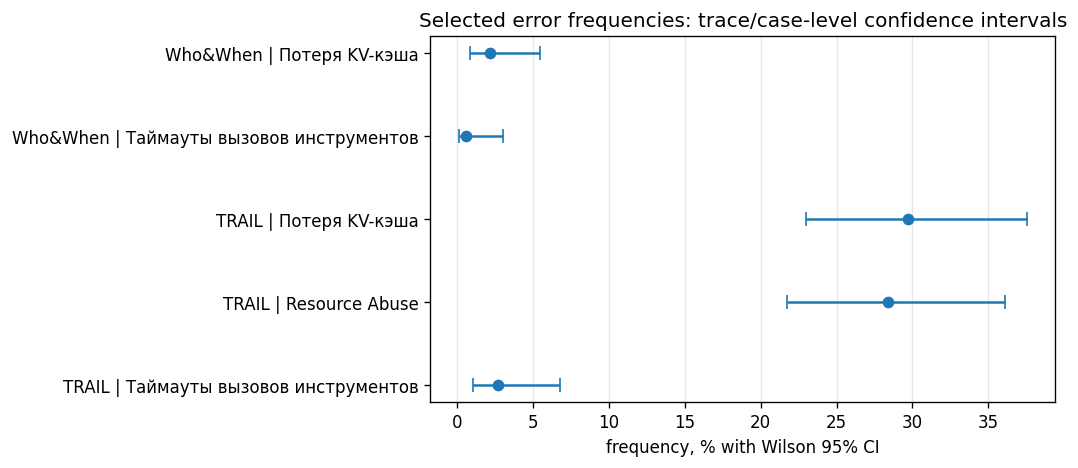

In [ ]:
plot_ci = frequency_ci[frequency_ci['denominator'].isin(['all traces', 'all cases'])].copy()
plot_ci['label'] = plot_ci['dataset'] + ' | ' + plot_ci['error']
plot_ci = plot_ci.sort_values(['dataset', 'p_hat_%'])

y = np.arange(len(plot_ci))
x = plot_ci['p_hat_%'].to_numpy()
xerr = np.vstack([
    x - plot_ci['wilson_low_%'].to_numpy(),
    plot_ci['wilson_high_%'].to_numpy() - x,
])

plt.figure(figsize=(9, max(4, 0.55 * len(plot_ci))))
plt.errorbar(x, y, xerr=xerr, fmt='o', capsize=4)
plt.yticks(y, plot_ci['label'])
plt.xlabel('frequency, % with Wilson 95% CI')
plt.title('Selected error frequencies: trace/case-level confidence intervals')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Вывод по пункту 4

- **TRAIL trace-level**: `Потеря KV-кэша` 44/148 = 29.73%, Wilson 95% CI: 22.95-37.53%; `Resource Abuse` 42/148 = 28.38%, CI: 21.73-36.12%. Это не редкие события в TRAIL, но интервалы все еще широкие, поэтому вероятность можно назвать только грубо.
- **TRAIL timeout**: 4/148 = 2.70%, Wilson 95% CI: 1.06-6.74%. Наблюдений меньше 5, поэтому данных недостаточно для уверенной оценки редкой ошибки.
- **Who&When KV/context**: 4/184 = 2.17%, Wilson 95% CI: 0.85-5.46%. Тоже недостаточно positives.
- **Who&When timeout**: 1/184 = 0.54%, Wilson 95% CI: 0.10-3.00%. Это самый неустойчивый случай: один пример не позволяет надежно назвать вероятность.
- По столбцу `additional_n_for_pm2pp` видно, сколько дополнительных case/trace примерно нужно для абсолютной точности ±2 п.п. при текущей точечной оценке. Для редких ошибок это ориентир, но не замена новым наблюдениям: сначала нужно хотя бы поднять число positives выше 5-10.
- Итог: для KV-cache и Resource Abuse в TRAIL данных достаточно для грубой оценки и моделирования; для timeout и Who&When-редких классов нужен либо больший датасет, либо объединение близких категорий/иерархическая модель.
